# TV2 – W2-02 – Baseline B0 Results & Demo

**CameraTrapML** · Ứng dụng học máy hỗ trợ nhận dạng một số loài động vật ưu tiên bảo tồn tại Trường Sơn từ ảnh bẫy camera.

**Thành viên:** TV2 — Baseline & Evaluation · **Công việc:** W2-02

Mục tiêu tuần 2 là chạy baseline **ResNet18 pretrained ImageNet trên toàn ảnh**, đóng băng backbone và chỉ huấn luyện lớp phân loại cuối. Checkpoint được chọn bằng **validation macro-F1**; test không tham gia chọn mô hình.

Notebook này đọc kết quả có sẵn, trực quan hóa và chạy suy luận từ checkpoint. Pipeline chính thức vẫn nằm trong `scripts/prepare_b0_pilot.py`, `scripts/train_b0.py` và `scripts/validate_b0.py`.

> **Phạm vi trình bày:** tập thử nhỏ của tuần 2, chưa phải toàn bộ pilot hoặc hiệu năng cuối cùng. Các con số bên dưới được đọc/tính từ artifact thực tế.

### Cách mở và Run All

- **VS Code / Jupyter:** mở notebook trong checkout của repository và chọn kernel có các thư viện trong `requirements-tv2.txt` (gồm pandas qua seaborn), cùng IPython/Jupyter.
- **Google Colab:** có thể mở trực tiếp file `.ipynb` để xem output đã lưu. Để Run All, đưa cả source repo, thư mục `experiments/B0_run01/` và các ảnh gốc tương ứng trong `data/images/` vào runtime, giữ nguyên cấu trúc thư mục; đặt thư mục làm việc tại repo. Checkpoint và ảnh bị Git bỏ qua nên clone repo đơn thuần chưa đủ.
- Notebook tự tìm repo từ thư mục làm việc hoặc thư mục cha; cũng nhận repo nằm ngay trong thư mục làm việc. Không có đường dẫn máy cá nhân, lệnh cài đặt, tải dữ liệu hoặc train tự động.
- Khi dữ liệu local đầy đủ, Run All không cần Internet. Nếu thiếu ảnh minh họa, notebook ghi cảnh báo và tiếp tục; thiếu artifact cốt lõi sẽ được báo rõ.

## 1. Import và thiết lập

In [1]:
from pathlib import Path
import sys
import json
import hashlib
import re
import textwrap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
from PIL import Image
from IPython.display import display, Markdown, Image as DisplayImage

%matplotlib inline
pd.set_option('display.max_rows', 20)
pd.set_option('display.max_colwidth', 70)
plt.rcParams.update({'figure.dpi': 105, 'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.titleweight': 'bold'})
COLORS = {'train': '#146b77', 'val': '#dc8b37', 'best': '#934b68'}

In [2]:
cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents, *sorted(p for p in cwd.iterdir() if p.is_dir())]
PROJECT_ROOT = next((p for p in candidates
    if (p / 'src/models/b0.py').is_file() and (p / 'configs/b0.yaml').is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Chưa tìm thấy repo. Hãy đặt thư mục làm việc tại repo CameraTrapML.')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.evaluation.metrics import load_class_map
from src.data.b0_dataset import read_rows, image_path, inspect_images, FullImageDataset, make_transform
from src.models.b0 import build_b0, parameter_counts
from src.training.b0 import evaluate, set_seed
from torch.utils.data import DataLoader

RUN_DIR = PROJECT_ROOT / 'experiments/B0_run01'
DEVICE = torch.device('cpu')  # CPU đủ cho demo; phù hợp thiết bị của lượt train đã lưu.
torch.set_num_threads(min(4, torch.get_num_threads()))
display(pd.DataFrame({'Thành phần': ['Repository', 'Run', 'Torch', 'Torchvision', 'Demo device'],
                      'Giá trị': [PROJECT_ROOT.name, RUN_DIR.relative_to(PROJECT_ROOT).as_posix(),
                                 str(torch.__version__), str(torchvision.__version__), str(DEVICE)]}))

,Thành phần,Giá trị
0,Repository,Do_an
1,Run,experiments/B0_run01
2,Torch,2.13.0+cpu
3,Torchvision,0.28.0+cpu
4,Demo device,cpu


In [3]:
paths = {
    'config': RUN_DIR / 'config.yaml',
    'train': RUN_DIR / 'selected_train.jsonl', 'val': RUN_DIR / 'selected_val.jsonl',
    'used_train': RUN_DIR / 'used_train.jsonl', 'used_val': RUN_DIR / 'used_val.jsonl',
    'class_map': PROJECT_ROOT / 'data/processed/v1/class_map.json',
    'log': RUN_DIR / 'logs/train_log.csv',
    'metrics': RUN_DIR / 'results/val_metrics.json',
    'reload': RUN_DIR / 'results/reload_validation.json',
    'confusion_matrix': RUN_DIR / 'results/confusion_matrix.png',
    'learning_curves': RUN_DIR / 'results/learning_curves.png',
    'checkpoint': RUN_DIR / 'checkpoints/best_model.pth',
    'report': PROJECT_ROOT / 'reports/tv2/TV2_W2.md',
}
missing_artifacts = [p.relative_to(PROJECT_ROOT).as_posix() for p in paths.values() if not p.is_file()]
if missing_artifacts:
    raise FileNotFoundError('Thiếu artifact: ' + ', '.join(missing_artifacts))
def sha256(path):
    with path.open('rb') as stream:
        return hashlib.file_digest(stream, 'sha256').hexdigest()
artifact_hashes_before = {key: sha256(path) for key, path in paths.items()}
# config.yaml của dự án dùng cú pháp JSON, hợp lệ theo YAML 1.2.
config = json.loads(paths['config'].read_text(encoding='utf-8'))
metrics = json.loads(paths['metrics'].read_text(encoding='utf-8'))
reload_record = json.loads(paths['reload'].read_text(encoding='utf-8'))
report_text = paths['report'].read_text(encoding='utf-8')
IMAGE_ROOT = PROJECT_ROOT / config['data']['image_root']
set_seed(config['experiment']['seed'])

## 2. Thông tin dataset và phân bố lớp

Đọc danh sách train/validation đã chọn và danh sách thực dùng của `B0_run01`. Notebook không đọc manifest test. Mọi ID và nhãn dưới đây giữ nguyên từ artifact TV1/TV2.

In [4]:
class_ids, class_names = load_class_map(paths['class_map'])
assert class_ids == list(range(len(class_names)))
train_rows = read_rows(paths['train'], 'train', class_names)
val_rows = read_rows(paths['val'], 'val', class_names)
used_train = read_rows(paths['used_train'], 'train', class_names)
used_val = read_rows(paths['used_val'], 'val', class_names)
assert {r['image_id'] for r in train_rows}.isdisjoint(r['image_id'] for r in val_rows)
assert all(r in train_rows for r in used_train) and all(r in val_rows for r in used_val)
for key, hash_key in [('used_train', 'train_manifest_sha256'),
                      ('used_val', 'validation_manifest_sha256'), ('class_map', 'class_map_sha256')]:
    assert sha256(paths[key]) == config['dataset'][hash_key], f'Hash dữ liệu không khớp: {key}'
train_df, val_df = pd.DataFrame(train_rows), pd.DataFrame(val_rows)
distribution = pd.DataFrame({'Class': class_names})
distribution['Train'] = distribution['Class'].map(train_df['label'].value_counts()).fillna(0).astype(int)
distribution['Validation'] = distribution['Class'].map(val_df['label'].value_counts()).fillna(0).astype(int)
display(Markdown(f'**Đã chọn:** {len(train_rows)} train + {len(val_rows)} validation · '
                 f'**Thực dùng:** {len(used_train)} train + {len(used_val)} validation · '
                 f'**Số lớp:** {len(class_names)}. Đây là tập thử tuần 2, **không phải toàn bộ pilot**. '
                 '**Test không được dùng.**'))
display(distribution.style.hide(axis='index'))

**Đã chọn:** 128 train + 64 validation · **Thực dùng:** 128 train + 64 validation · **Số lớp:** 8. Đây là tập thử tuần 2, **không phải toàn bộ pilot**. **Test không được dùng.**

Class,Train,Validation
large_antlered_muntjac,16,8
annamite_striped_rabbit,16,8
sambar,16,8
chinese_serow,16,8
common_palm_civet,16,8
masked_palm_civet,16,8
silver_pheasant,16,8
eurasian_wild_pig,16,8


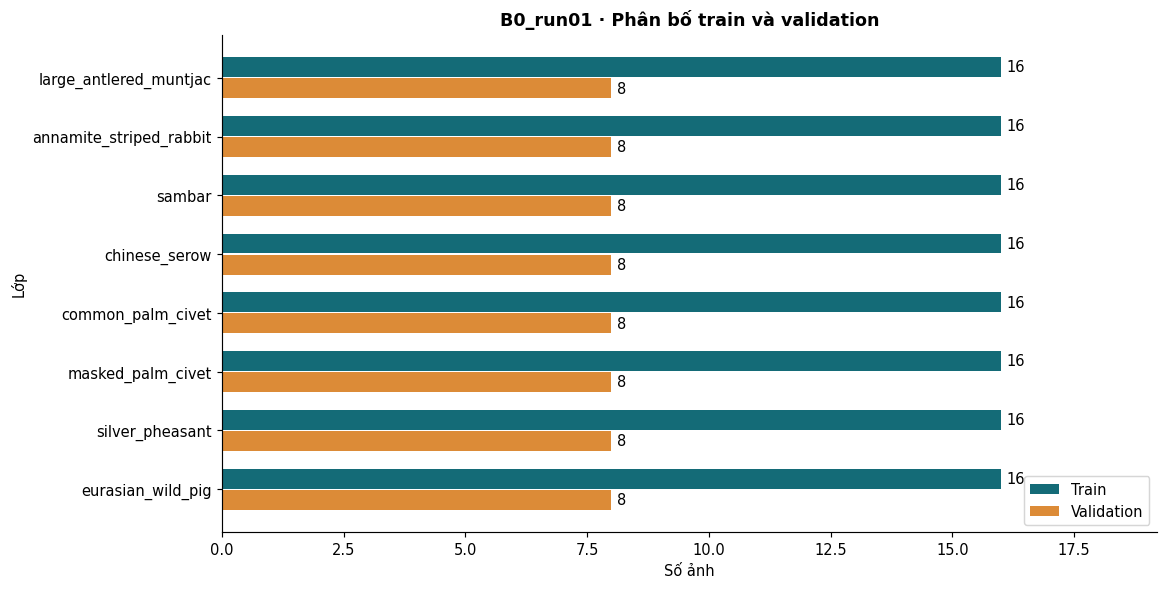

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5), layout='constrained')
y = np.arange(len(distribution))
bars_train = ax.barh(y - 0.18, distribution['Train'], 0.34, label='Train', color=COLORS['train'])
bars_val = ax.barh(y + 0.18, distribution['Validation'], 0.34, label='Validation', color=COLORS['val'])
ax.set_yticks(y, distribution['Class'])
ax.invert_yaxis()
ax.bar_label(bars_train, padding=4)
ax.bar_label(bars_val, padding=4)
ax.set_xlim(0, distribution[['Train', 'Validation']].to_numpy().max() * 1.2)
ax.set(xlabel='Số ảnh', ylabel='Lớp', title='B0_run01 · Phân bố train và validation')
ax.legend(loc='lower right')
plt.show()

## 3. Ảnh mẫu toàn cảnh

Mỗi lớp lấy một ảnh train có image ID nhỏ nhất trong danh sách đã chọn. Đây là ảnh gốc toàn khung, không dùng box hoặc crop của TV3. Ảnh chỉ được thu nhỏ để hiển thị; tiền xử lý đầu vào model được trình bày ở phần cấu hình.

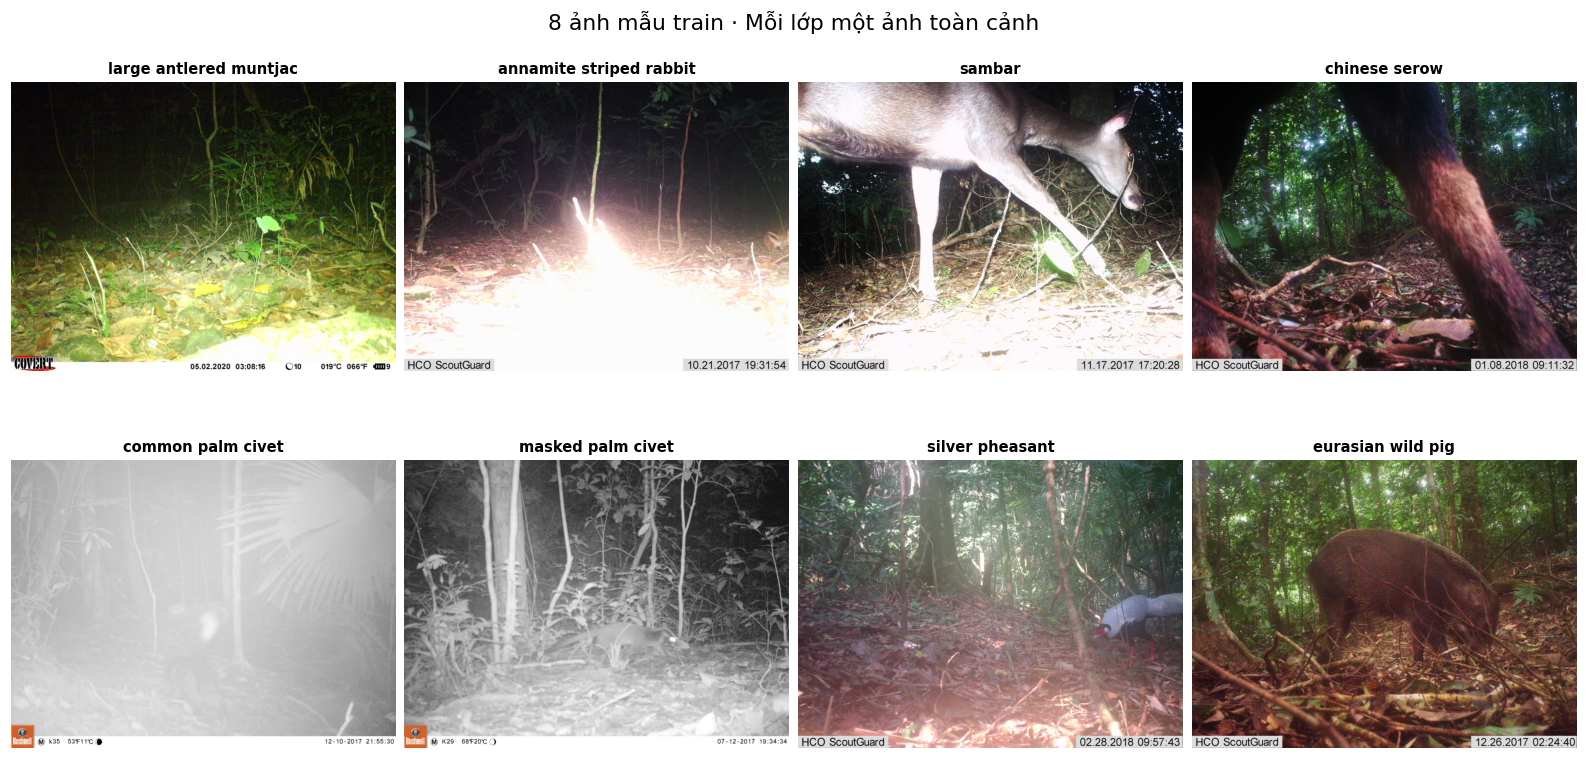

In [6]:
def full_image_for_display(row):
    try:
        with Image.open(image_path(IMAGE_ROOT, row)) as source:
            image = source.convert('RGB')
            image.thumbnail((960, 720))  # Giữ toàn bộ khung hình và tỷ lệ ảnh.
        return image, None
    except (OSError, ValueError) as error:
        return None, f"Không đọc được ảnh {row['image_id']}: {type(error).__name__}"

train_examples = [min((r for r in train_rows if r['class_id'] == i), key=lambda r: r['image_id'])
                  for i in class_ids]
fig, axes = plt.subplots(2, 4, figsize=(15, 7.5), layout='constrained')
sample_warnings = []
for ax, row in zip(axes.flat, train_examples):
    picture, warning = full_image_for_display(row)
    if picture is not None:
        ax.imshow(picture)
    else:
        ax.text(0.5, 0.5, 'Ảnh chưa có / không đọc được', ha='center', va='center', wrap=True)
        sample_warnings.append(warning)
    ax.set_title(textwrap.fill(row['label'].replace('_', ' '), 24), fontsize=10)
    ax.axis('off')
fig.suptitle('8 ảnh mẫu train · Mỗi lớp một ảnh toàn cảnh', fontsize=15)
plt.show()
if sample_warnings:
    display(Markdown('**Cảnh báo ảnh mẫu:**\n\n' + '\n'.join('- ' + w for w in sample_warnings)))

## 4. Cấu hình B0 đã sử dụng

In [7]:
configuration = {
    'Model': config['model']['backbone'], 'Pretrained weights': config['model']['weights'],
    'Pretrained source': config['model']['pretrained'], 'Freeze backbone': config['model']['freeze_backbone'],
    'Num classes': config['model']['num_classes'], 'Seed': config['experiment']['seed'],
    'Image size': config['data']['image_size'], 'Batch size': config['data']['batch_size'],
    'Learning rate': config['training']['lr'], 'Optimizer': config['training']['optimizer'],
    'Weight decay': config['training']['weight_decay'], 'Epochs tối đa': config['training']['epochs'],
    'Early stopping patience': config['training']['early_stopping_patience'],
    'Checkpoint metric': config['training']['checkpoint_metric'],
    'Thiết bị khi train': config['environment']['device'],
}
display(pd.DataFrame(configuration.items(), columns=['Cấu hình', 'Giá trị']).style.hide(axis='index'))
display(Markdown('**Train:** `' + config['preprocessing']['train'] + '`\n\n'
                 '**Validation:** `' + config['preprocessing']['validation'] + '`\n\n'
                 'Validation dùng CenterCrop cố định; không có augmentation ngẫu nhiên. '
                 'Full-image ở đây là không cắt theo bounding box; vẫn áp dụng tiền xử lý W1 đã thống nhất.'))

Cấu hình,Giá trị
Model,resnet18
Pretrained weights,ResNet18_Weights.DEFAULT
Pretrained source,ImageNet-1K
Freeze backbone,True
Num classes,8
Seed,42
Image size,224
Batch size,32
Learning rate,0.001000
Optimizer,adam


**Train:** `Resize(256), RandomCrop(224), RandomHorizontalFlip(0.5), ColorJitter(0.2,0.2,0.1,0.05), ToTensor, ImageNet Normalize`

**Validation:** `Resize(256), CenterCrop(224), ToTensor, ImageNet Normalize`

Validation dùng CenterCrop cố định; không có augmentation ngẫu nhiên. Full-image ở đây là không cắt theo bounding box; vẫn áp dụng tiền xử lý W1 đã thống nhất.

## 5. Kiến trúc model

**B0 sử dụng ResNet18 pretrained ImageNet. Backbone bị đóng băng và chỉ lớp phân loại cuối được huấn luyện.**

Cell sau tái sử dụng `build_b0` để kiểm tra cấu trúc và số tham số. `pretrained=False` chỉ tránh tải trọng số từ Internet ở bước dựng khung; chưa chạy suy luận trên model này. Toàn bộ backbone pretrained và FC đã học sẽ được khôi phục từ checkpoint ở phần 11.

In [8]:
architecture_model = build_b0(config['model']['num_classes'], pretrained=False)
parameter_summary = parameter_counts(architecture_model)
trainable_names = [name for name, p in architecture_model.named_parameters() if p.requires_grad]
assert trainable_names == ['fc.weight', 'fc.bias']
assert parameter_summary == config['model']['parameter_counts']
display(pd.DataFrame({'Thông tin': ['Architecture', 'Pretrained source', 'Final classifier', 'Num classes',
                                    'Total parameters', 'Trainable parameters', 'Frozen parameters'],
                      'Giá trị': [config['model']['backbone'], config['model']['pretrained'], str(architecture_model.fc),
                                 config['model']['num_classes'], parameter_summary['total'],
                                 parameter_summary['trainable'], parameter_summary['frozen']]}))
print('Trainable parameters:', ', '.join(trainable_names))
del architecture_model

,Thông tin,Giá trị
0,Architecture,resnet18
1,Pretrained source,ImageNet-1K
2,Final classifier,"Linear(in_features=512, out_features=8, bias=True)"
3,Num classes,8
4,Total parameters,11180616
5,Trainable parameters,4104
6,Frozen parameters,11176512


Trainable parameters: fc.weight, fc.bias


## 6. Training history và learning curves

In [9]:
history = pd.read_csv(paths['log'])
assert history['epoch'].is_unique and history['epoch'].is_monotonic_increasing
assert np.isfinite(history.select_dtypes(include='number').to_numpy()).all()
best_epoch_from_log = int(history.loc[history['val_macro_f1'].idxmax(), 'epoch'])
assert best_epoch_from_log == metrics['best_epoch']
display(Markdown(f"Log ghi **{len(history)} epoch**, từ {int(history['epoch'].min())} đến "
                 f"{int(history['epoch'].max())}. Best epoch theo validation macro-F1: **{best_epoch_from_log}**."))
history_view = history if len(history) <= 20 else pd.concat([history.head(10), history.tail(10)])
display(history_view.style.format(precision=4).format({'epoch': '{:.0f}', 'learning_rate': '{:.4f}'}).hide(axis='index'))

Log ghi **9 epoch**, từ 1 đến 9. Best epoch theo validation macro-F1: **4**.

epoch,train_loss,val_loss,val_macro_f1,val_macro_precision,val_macro_recall,val_accuracy,learning_rate
1,2.142229,1.957553,0.227909,0.333446,0.218750,0.218750,0.0010
2,1.925491,1.908672,0.198063,0.215972,0.250000,0.250000,0.0010
3,1.853308,1.844415,0.264970,0.411330,0.296875,0.296875,0.0010
4,1.737651,1.788723,0.361687,0.467735,0.375000,0.375000,0.0010
5,1.629221,1.748203,0.341324,0.521230,0.343750,0.343750,0.0010
6,1.585841,1.712882,0.334575,0.527051,0.375000,0.375000,0.0010
7,1.493769,1.675745,0.264729,0.375280,0.328125,0.328125,0.0010
8,1.468015,1.650774,0.245127,0.361203,0.281250,0.281250,0.0010
9,1.423473,1.629012,0.235885,0.271528,0.265625,0.265625,0.0010


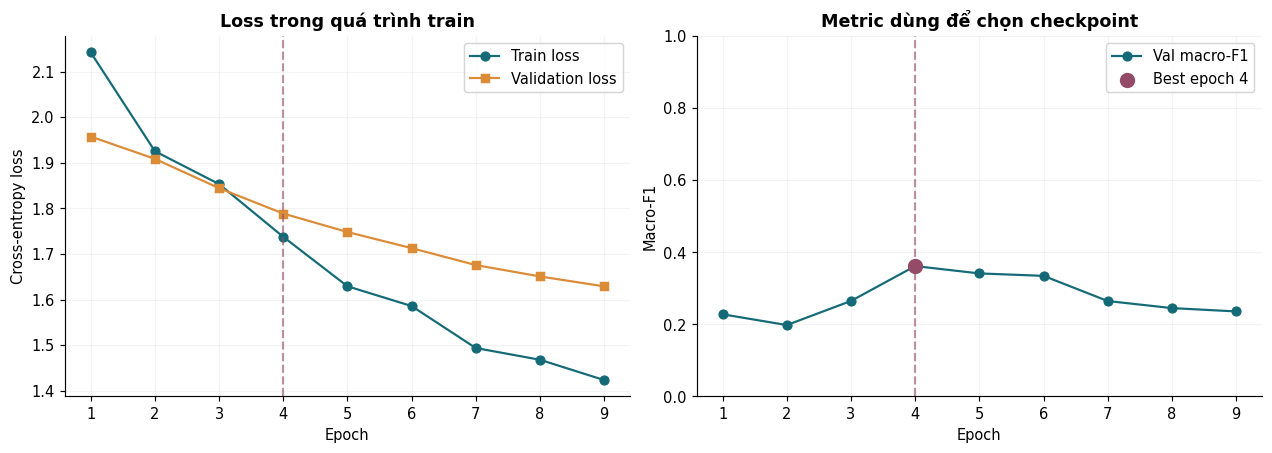

Biểu đồ được vẽ lại từ `train_log.csv`; hình gốc cũng được giữ tại `experiments/B0_run01/results/learning_curves.png`.

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), layout='constrained')
axes[0].plot(history['epoch'], history['train_loss'], 'o-', label='Train loss', color=COLORS['train'])
axes[0].plot(history['epoch'], history['val_loss'], 's-', label='Validation loss', color=COLORS['val'])
axes[0].set(xlabel='Epoch', ylabel='Cross-entropy loss', title='Loss trong quá trình train')
axes[1].plot(history['epoch'], history['val_macro_f1'], 'o-', color=COLORS['train'], label='Val macro-F1')
axes[1].scatter([best_epoch_from_log], [metrics['macro_f1']], s=90, color=COLORS['best'], zorder=5,
                label=f'Best epoch {best_epoch_from_log}')
axes[1].set(xlabel='Epoch', ylabel='Macro-F1', ylim=(0, 1), title='Metric dùng để chọn checkpoint')
for ax in axes:
    ax.axvline(best_epoch_from_log, color=COLORS['best'], linestyle='--', alpha=0.6)
    ax.set_xticks(history['epoch'])
    ax.grid(alpha=0.15)
    ax.legend()
plt.show()
display(Markdown('Biểu đồ được vẽ lại từ `train_log.csv`; hình gốc cũng được giữ tại '
                 '`experiments/B0_run01/results/learning_curves.png`.'))

## 7. Best epoch

Checkpoint được chọn theo **validation macro-F1 lớn nhất**, không theo train loss hay test. Nếu đồng hạng, quy tắc trong pipeline giữ epoch tốt nhất xuất hiện đầu tiên.

In [11]:
best_row = history.loc[history['epoch'].eq(metrics['best_epoch'])].iloc[0]
best_summary = pd.DataFrame({
    'Best epoch': [int(best_row['epoch'])], 'Train loss': [best_row['train_loss']],
    'Validation loss': [best_row['val_loss']], 'Macro-F1': [best_row['val_macro_f1']],
    'Precision': [best_row['val_macro_precision']], 'Recall': [best_row['val_macro_recall']],
    'Accuracy': [best_row['val_accuracy']],
})
display(best_summary.style.format(precision=6).format({'Best epoch': '{:.0f}'}).hide(axis='index'))

Best epoch,Train loss,Validation loss,Macro-F1,Precision,Recall,Accuracy
4,1.737651,1.788723,0.361687,0.467735,0.375000,0.375000


## 8. Validation results

Các metric dưới đây đọc trực tiếp từ `val_metrics.json`. Macro averaging tính đủ các lớp theo class map, với `zero_division=0`; accuracy là chỉ số bổ sung.

In [12]:
metric_labels = {'macro_f1': 'Macro-F1', 'macro_precision': 'Macro-Precision',
                 'macro_recall': 'Macro-Recall', 'accuracy': 'Accuracy'}
assert all(np.isfinite(metrics[k]) and 0 <= metrics[k] <= 1 for k in metric_labels)
metric_table = pd.DataFrame({'Metric': list(metric_labels.values()),
                             'Value': [metrics[key] for key in metric_labels]})
display(metric_table.style.format({'Value': '{:.6f}'}).hide(axis='index'))
per_class = pd.DataFrame([
    {'Class': name, 'Precision': metrics['per_class'][name]['precision'],
     'Recall': metrics['per_class'][name]['recall'], 'F1': metrics['per_class'][name]['f1-score'],
     'Support': int(metrics['per_class'][name]['support'])} for name in class_names
])
assert per_class['Support'].sum() == metrics['support'] == len(used_val)
display(per_class.style.format({'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1': '{:.4f}', 'Support': '{:.0f}'}).hide(axis='index'))

Metric,Value
Macro-F1,0.361687
Macro-Precision,0.467735
Macro-Recall,0.375000
Accuracy,0.375000


Class,Precision,Recall,F1,Support
large_antlered_muntjac,0.6667,0.2500,0.3636,8
annamite_striped_rabbit,0.3333,0.7500,0.4615,8
sambar,0.5000,0.2500,0.3333,8
chinese_serow,1.0000,0.2500,0.4000,8
common_palm_civet,0.1111,0.1250,0.1176,8
masked_palm_civet,0.2000,0.1250,0.1538,8
silver_pheasant,0.7000,0.8750,0.7778,8
eurasian_wild_pig,0.2308,0.3750,0.2857,8


## 9. Confusion matrix

Trục dọc là nhãn thật, trục ngang là nhãn dự đoán. Màu và số trong hình là tỷ lệ chuẩn hóa theo từng hàng; đường chéo là dự đoán đúng. Ma trận giúp nhận ra cặp lớp dễ nhầm, nhưng số ảnh validation mỗi lớp rất ít nên không kết luận quá mức.

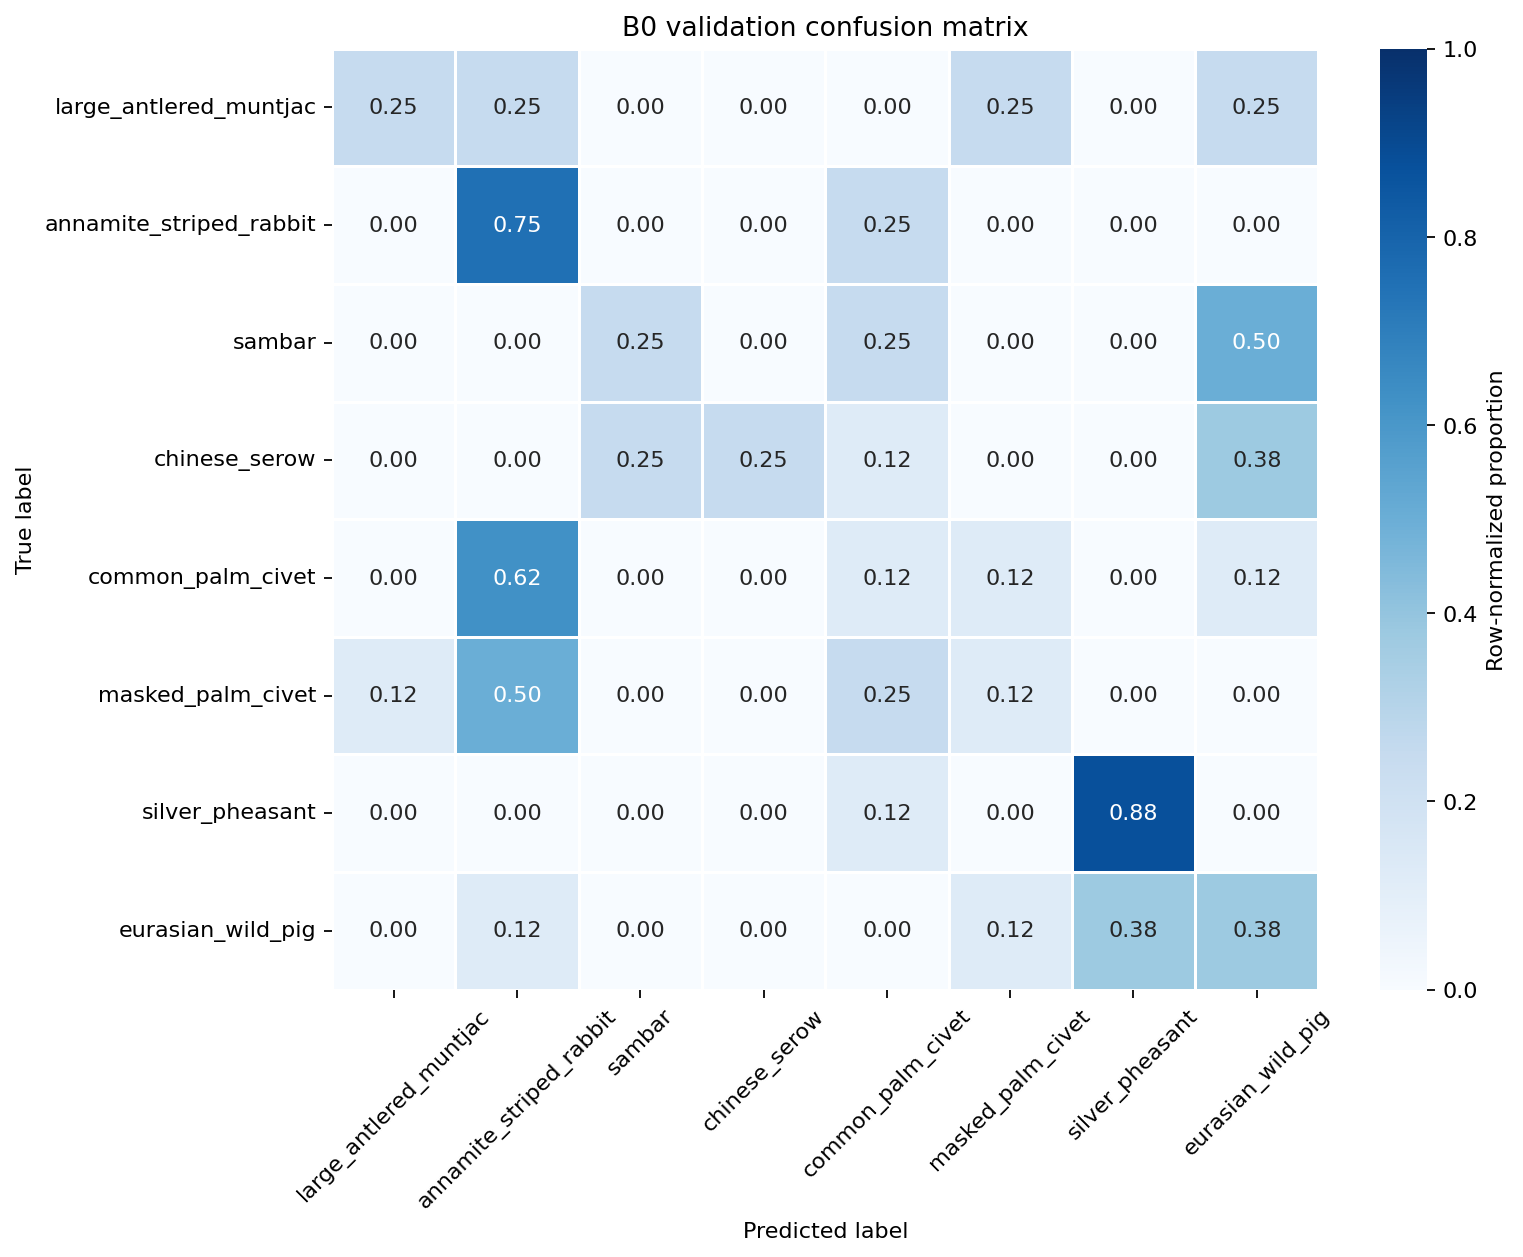

Đối chiếu ma trận JSON: 64 ảnh, 24 dự đoán đúng.


In [13]:
confusion = np.asarray(metrics['confusion_matrix'], dtype=int)
assert confusion.shape == (len(class_names), len(class_names))
assert confusion.sum() == metrics['support']
display(DisplayImage(filename=str(paths['confusion_matrix']), width=1000))
print(f'Đối chiếu ma trận JSON: {confusion.sum()} ảnh, {np.trace(confusion)} dự đoán đúng.')

## 10. Checkpoint thực tế

Đọc checkpoint local bằng `torch.load(..., map_location="cpu", weights_only=True)`. Chỉ hiển thị metadata; không dump state dict và không ghi checkpoint mới.

In [14]:
checkpoint = torch.load(paths['checkpoint'], map_location='cpu', weights_only=True)
assert checkpoint['config'] == config
assert checkpoint['class_to_idx'] == dict(zip(class_names, class_ids))
assert checkpoint['idx_to_class'] == dict(zip(class_ids, class_names))
assert checkpoint['epoch'] == metrics['best_epoch']
checkpoint_bytes = paths['checkpoint'].stat().st_size
checkpoint_digest = sha256(paths['checkpoint'])
assert checkpoint_digest == reload_record['checkpoint_sha256']
checkpoint_info = {
    'Checkpoint path': paths['checkpoint'].relative_to(PROJECT_ROOT).as_posix(),
    'File exists': paths['checkpoint'].is_file(), 'File size MB (10^6 bytes)': checkpoint_bytes / 1_000_000,
    'File size bytes': checkpoint_bytes, 'Epoch': checkpoint['epoch'],
    'Best validation macro-F1': checkpoint['best_val_macro_f1'],
    'Num classes': checkpoint['num_classes'], 'Model name': checkpoint['model_name'],
    'Freeze backbone': checkpoint['freeze_backbone'], 'Seed': checkpoint['seed'],
}
display(pd.DataFrame(checkpoint_info.items(), columns=['Metadata', 'Giá trị']).style.hide(axis='index'))
print('SHA-256:', checkpoint_digest)

Metadata,Giá trị
Checkpoint path,experiments/B0_run01/checkpoints/best_model.pth
File exists,True
File size MB (10^6 bytes),44.837567
File size bytes,44837567
Epoch,4
Best validation macro-F1,0.361687
Num classes,8
Model name,resnet18
Freeze backbone,True
Seed,42


SHA-256: d1ba497f1c21a5a259a99f55335d47288ee047f7f1c6236ec8b8dfa439649680


In [15]:
# Đối chiếu dung lượng ghi trong report mà không sửa report hoặc checkpoint.
reported_size_match = re.search(r'Dung lượng:\s*\*\*([\d.]+) bytes', report_text)
if reported_size_match:
    reported_bytes = int(reported_size_match.group(1).replace('.', ''))
    if reported_bytes != checkpoint_bytes:
        display(Markdown(f'> **Ghi chú artifact:** report Markdown ghi {reported_bytes:,} bytes; '
                         f'file checkpoint hiện tại và reload record ghi {checkpoint_bytes:,} bytes. '
                         'Notebook dùng thông tin đọc trực tiếp từ file, không thay đổi artifact.'))

> **Ghi chú artifact:** report Markdown ghi 44,837,375 bytes; file checkpoint hiện tại và reload record ghi 44,837,567 bytes. Notebook dùng thông tin đọc trực tiếp từ file, không thay đổi artifact.

## 11. Checkpoint reload verification

Khởi tạo một model mới bằng code dự án, nạp toàn bộ state dict với `strict=True`, rồi chuyển sang `eval()`. Nếu ảnh local đầy đủ, cell sau chạy lại toàn bộ validation của run bằng hàm `evaluate` có sẵn; không train.

Nếu thiếu ảnh, notebook chỉ trình bày biên bản `reload_validation.json` đã lưu và báo rõ phần validation hiện tại chưa chạy. Không tính metric trên một tập con thiếu ảnh rồi gọi đó là kết quả của toàn bộ validation.

In [16]:
model = build_b0(checkpoint['num_classes'], pretrained=False).to(DEVICE)
load_result = model.load_state_dict(checkpoint['model_state_dict'], strict=True)
model.eval()
print('Model mới: YES | load_state_dict: PASS')
print('Missing keys:', load_result.missing_keys, '| Unexpected keys:', load_result.unexpected_keys)
valid_val_rows, val_image_errors = inspect_images(used_val, IMAGE_ROOT)
live_reload_verified = False
if not val_image_errors:
    validation_loader = DataLoader(FullImageDataset(used_val, IMAGE_ROOT, make_transform(config, False)),
                                   batch_size=config['data']['batch_size'], shuffle=False, num_workers=0)
    live_metrics, live_true, live_pred, live_val_loss = evaluate(model, validation_loader, DEVICE, paths['class_map'])
    compared_metrics = live_metrics
    assert len(live_true) == len(used_val)
    assert live_metrics['confusion_matrix'].tolist() == metrics['confusion_matrix']
    comparison_source = f'Validation chạy lại trong notebook: {len(live_true)} ảnh.'
    live_reload_verified = True
else:
    compared_metrics = reload_record['validation_metrics']
    comparison_source = (f'Chỉ đọc biên bản reload đã lưu. Chưa chạy validation hiện tại: '
                         f'{len(val_image_errors)} ảnh thiếu/hỏng; không loại ảnh âm thầm.')
display(Markdown('**Nguồn đối chiếu:** ' + comparison_source))

Model mới: YES | load_state_dict: PASS
Missing keys: [] | Unexpected keys: []


**Nguồn đối chiếu:** Validation chạy lại trong notebook: 64 ảnh.

In [17]:
reload_comparison = pd.DataFrame([
    {'Metric': label, 'Original': metrics[key], 'Reloaded': compared_metrics[key],
     'Difference': abs(metrics[key] - compared_metrics[key])}
    for key, label in metric_labels.items()
])
assert reload_record['reload_successful']
assert (reload_comparison['Difference'] <= 1e-9).all()
assert all(abs(compared_metrics[key] - reload_record['validation_metrics'][key]) <= 1e-9
           for key in metric_labels)
display(reload_comparison.style.format({'Original': '{:.6f}', 'Reloaded': '{:.6f}',
                                      'Difference': '{:.2e}'}).hide(axis='index'))
if live_reload_verified:
    display(Markdown('**Checkpoint đã được load lại trên một model mới và cho cùng kết quả validation.** '
                     'Phép kiểm tra xác nhận khả năng tái lập khi reload trong môi trường hiện tại; '
                     'không thay thế kiểm tra train lại trên mọi phần cứng/phiên bản thư viện.'))
else:
    display(Markdown('Biên bản đã lưu xác nhận reload nhất quán. Cần đủ ảnh local để kiểm chứng lại trong phiên này.'))

Metric,Original,Reloaded,Difference
Macro-F1,0.361687,0.361687,0.00e+00
Macro-Precision,0.467735,0.467735,0.00e+00
Macro-Recall,0.375000,0.375000,0.00e+00
Accuracy,0.375000,0.375000,0.00e+00


**Checkpoint đã được load lại trên một model mới và cho cùng kết quả validation.** Phép kiểm tra xác nhận khả năng tái lập khi reload trong môi trường hiện tại; không thay thế kiểm tra train lại trên mọi phần cứng/phiên bản thư viện.

## 12. Sample predictions trên validation

Chọn cố định ảnh có image ID nhỏ nhất của mỗi lớp trong validation **trước khi xem dự đoán**, không chọn riêng ví dụ đúng. Suy luận mới từ checkpoint best với đúng preprocessing validation. Hình minh họa giữ toàn khung; input model vẫn qua Resize/CenterCrop theo cấu hình.

**Prediction score** là điểm softmax lớn nhất; không phải xác suất đã được hiệu chuẩn. Cả dự đoán đúng và sai đều được hiển thị rõ.

In [18]:
prediction_rows = [min((r for r in used_val if r['class_id'] == i), key=lambda r: r['image_id'])
                   for i in class_ids]
usable_examples, prediction_errors = inspect_images(prediction_rows, IMAGE_ROOT)
prediction_records = []
if usable_examples:
    demo_loader = DataLoader(FullImageDataset(usable_examples, IMAGE_ROOT, make_transform(config, False)),
                            batch_size=len(usable_examples), shuffle=False, num_workers=0)
    demo_images, demo_targets = next(iter(demo_loader))
    with torch.inference_mode():
        logits = model(demo_images.to(DEVICE))
        assert torch.isfinite(logits).all()
        scores, predictions = logits.softmax(dim=1).max(dim=1)
    for row, predicted, score in zip(usable_examples, predictions.cpu().tolist(), scores.cpu().tolist()):
        prediction_records.append({'Image ID': row['image_id'], 'Ground Truth': row['label'],
                                   'Predicted Class': class_names[predicted], 'Prediction score': score,
                                   'Correct / Incorrect': 'Correct' if predicted == row['class_id'] else 'Incorrect'})
prediction_table = pd.DataFrame(prediction_records)
if not prediction_table.empty:
    display(prediction_table.style.format({'Prediction score': '{:.4f}'}).hide(axis='index'))
if prediction_errors:
    display(Markdown(f'**Cảnh báo:** {len(prediction_errors)} ảnh minh họa thiếu/hỏng; không thay bằng ảnh test.'))

Image ID,Ground Truth,Predicted Class,Prediction score,Correct / Incorrect
c857a802-8c29-11eb-a9f1-000d3a74c7de,large_antlered_muntjac,large_antlered_muntjac,0.2320,Correct
cb14a053-8c29-11eb-a313-000d3a74c7de,annamite_striped_rabbit,annamite_striped_rabbit,0.2219,Correct
c8a191f3-8c29-11eb-85de-000d3a74c7de,sambar,eurasian_wild_pig,0.2048,Incorrect
c87143f9-8c29-11eb-b191-000d3a74c7de,chinese_serow,eurasian_wild_pig,0.1979,Incorrect
cb1bcd11-8c29-11eb-983e-000d3a74c7de,common_palm_civet,masked_palm_civet,0.2989,Incorrect
c911a9ef-8c29-11eb-9d07-000d3a74c7de,masked_palm_civet,annamite_striped_rabbit,0.2270,Incorrect
c939ca26-8c29-11eb-81d6-000d3a74c7de,silver_pheasant,silver_pheasant,0.3381,Correct
c97a9807-8c29-11eb-8a05-000d3a74c7de,eurasian_wild_pig,silver_pheasant,0.2913,Incorrect


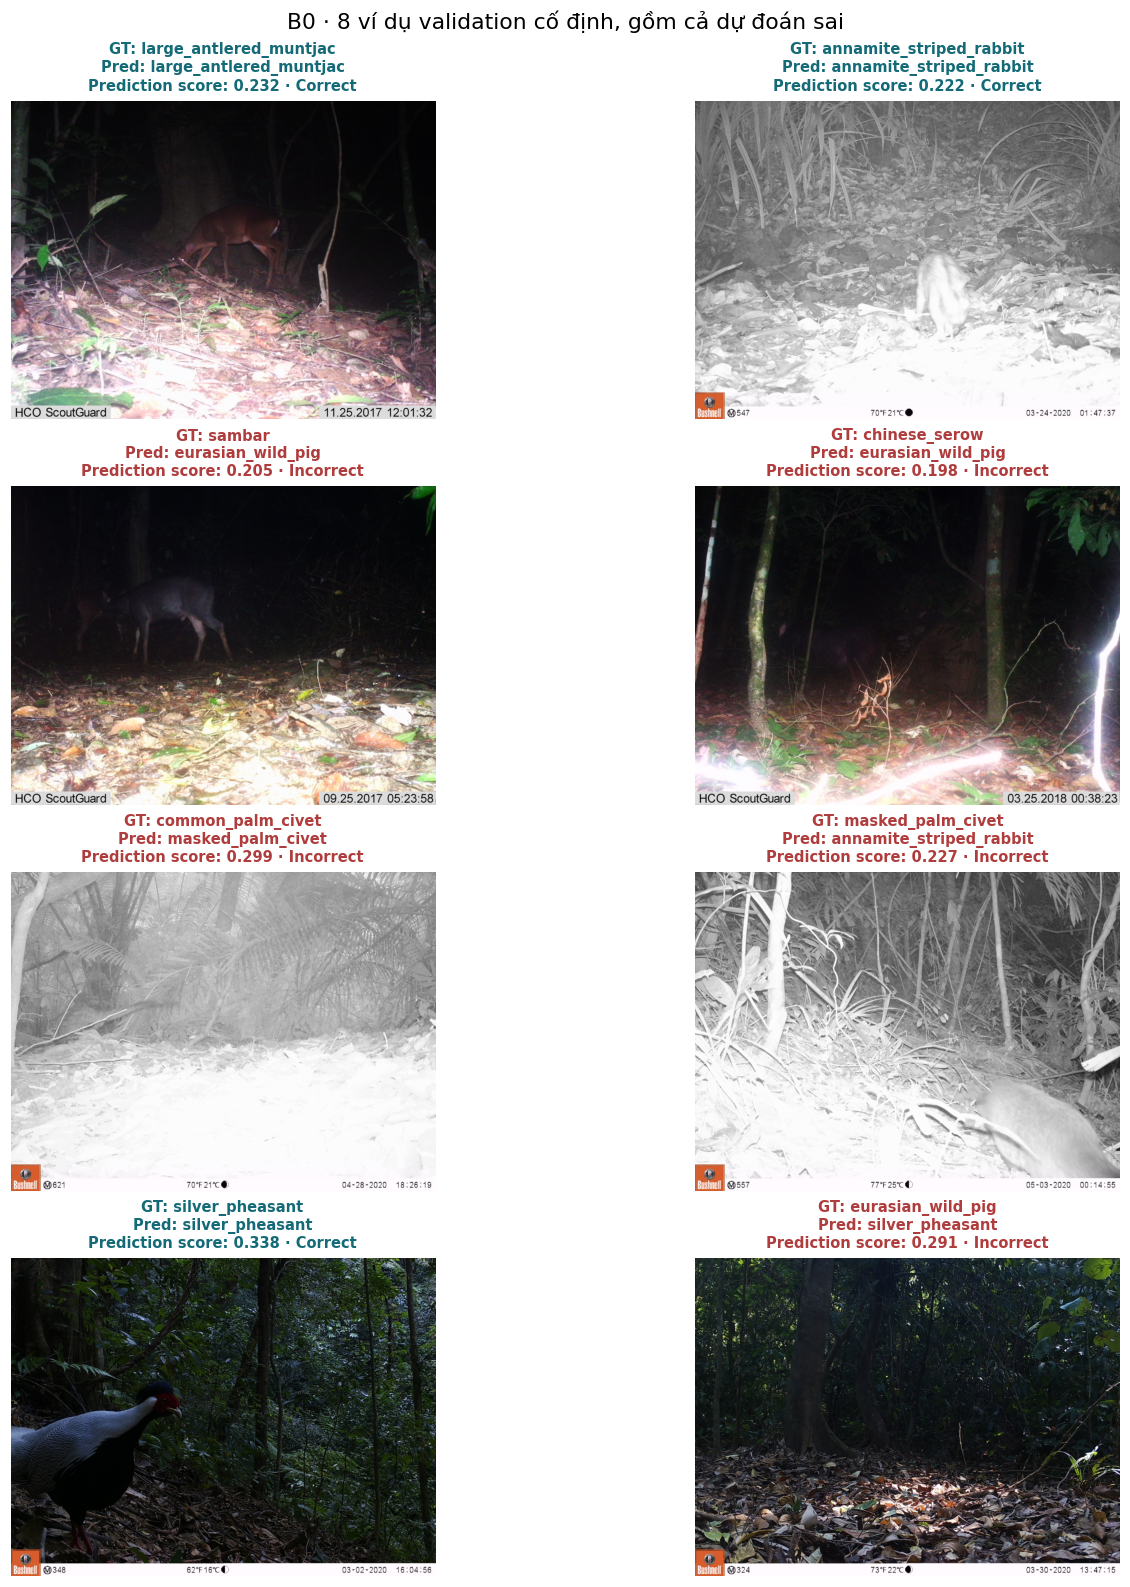

In [19]:
fig, axes = plt.subplots(4, 2, figsize=(13, 15), layout='constrained')
prediction_by_id = {r['Image ID']: r for r in prediction_records}
for ax, row in zip(axes.flat, prediction_rows):
    picture, warning = full_image_for_display(row)
    result = prediction_by_id.get(row['image_id'])
    if picture is not None:
        ax.imshow(picture)
    if result is None:
        ax.text(0.5, 0.5, 'Ảnh thiếu/hỏng — chưa có dự đoán', ha='center', va='center', transform=ax.transAxes)
        title, color = row['label'], '#666666'
    else:
        status = result['Correct / Incorrect']
        title = (f"GT: {result['Ground Truth']}\nPred: {result['Predicted Class']}\n"
                 f"Prediction score: {result['Prediction score']:.3f} · {status}")
        color = COLORS['train'] if status == 'Correct' else '#b03d3d'
    ax.set_title(title, fontsize=10, color=color, pad=7)
    ax.axis('off')
fig.suptitle('B0 · 8 ví dụ validation cố định, gồm cả dự đoán sai', fontsize=15)
plt.show()

## 13. Phân tích kết quả

Phân tích dưới đây lấy trực tiếp số liệu từ log, metric và confusion matrix. Kết quả phục vụ kiểm tra baseline; không khẳng định khả năng nhận dạng ngoài thực địa.

In [20]:
best_class = per_class.loc[per_class['F1'].idxmax()]
lowest_class = per_class.loc[per_class['F1'].idxmin()]
display(Markdown(f'''
- B0 dự đoán đúng **{int(np.trace(confusion))}/{metrics['support']}** ảnh validation: accuracy **{metrics['accuracy']:.2%}**, macro-F1 **{metrics['macro_f1']:.4f}**. Có tín hiệu phân loại ban đầu, nhưng điểm còn thấp.
- Train loss giảm từ **{history.iloc[0]['train_loss']:.4f}** xuống **{history.iloc[-1]['train_loss']:.4f}**. Validation macro-F1 đạt đỉnh ở epoch **{best_epoch_from_log}**, rồi còn **{history.iloc[-1]['val_macro_f1']:.4f}** ở epoch cuối. Vì vậy checkpoint không lấy từ epoch cuối.
- F1 cao nhất trong lượt này: **{best_class['Class']} ({best_class['F1']:.4f})**; thấp nhất: **{lowest_class['Class']} ({lowest_class['F1']:.4f})**. Mỗi lớp chỉ có **{int(per_class['Support'].min())} ảnh validation**, nên một vài dự đoán có thể làm tỷ lệ thay đổi đáng kể.
- Train chỉ có **{len(used_train)} ảnh** và backbone bị freeze. Các giới hạn này cần được cân nhắc khi phân tích sai số; chưa đủ bằng chứng để quy mọi lỗi cho một nguyên nhân cụ thể.
- B0 là mốc tham khảo cho B1 tuần 3. Khi so sánh, phải thống nhất danh sách ảnh và giao thức đánh giá; không so trực tiếp lượt này với mô hình dùng tập dữ liệu khác rồi quy khác biệt hoàn toàn cho kiến trúc.
'''))


- B0 dự đoán đúng **24/64** ảnh validation: accuracy **37.50%**, macro-F1 **0.3617**. Có tín hiệu phân loại ban đầu, nhưng điểm còn thấp.
- Train loss giảm từ **2.1422** xuống **1.4235**. Validation macro-F1 đạt đỉnh ở epoch **4**, rồi còn **0.2359** ở epoch cuối. Vì vậy checkpoint không lấy từ epoch cuối.
- F1 cao nhất trong lượt này: **silver_pheasant (0.7778)**; thấp nhất: **common_palm_civet (0.1176)**. Mỗi lớp chỉ có **8 ảnh validation**, nên một vài dự đoán có thể làm tỷ lệ thay đổi đáng kể.
- Train chỉ có **128 ảnh** và backbone bị freeze. Các giới hạn này cần được cân nhắc khi phân tích sai số; chưa đủ bằng chứng để quy mọi lỗi cho một nguyên nhân cụ thể.
- B0 là mốc tham khảo cho B1 tuần 3. Khi so sánh, phải thống nhất danh sách ảnh và giao thức đánh giá; không so trực tiếp lượt này với mô hình dùng tập dữ liệu khác rồi quy khác biệt hoàn toàn cho kiến trúc.


## 14. Limitations

In [21]:
display(Markdown(f'''
- Chỉ **{len(used_train)} train**, **{len(used_val)} validation**, **{len(class_names)} lớp**; chưa dùng toàn bộ pilot.
- Backbone **frozen**, chỉ FC được train. Môi trường của run: **{config['environment']['device'].upper()}**.
- Validation nhỏ, các ảnh có thể thuộc cùng chuỗi; số ảnh không đồng nghĩa với số quan sát hoàn toàn độc lập.
- Chưa đánh giá test; không dùng test để chọn checkpoint hoặc chỉnh tham số.
- Chưa fine-tune B1; chưa làm B2 crop. Kết quả chỉ phục vụ baseline tuần 2.
- Softmax score trong demo chưa được hiệu chuẩn. Notebook không suy ra tình trạng bảo tồn của loài từ kết quả phân loại.
- Checkpoint và ảnh local không nằm trong Git. Khi chuyển máy cần mang theo artifact; xem output đã lưu không đồng nghĩa với đã chạy lại trên máy mới.
'''))


- Chỉ **128 train**, **64 validation**, **8 lớp**; chưa dùng toàn bộ pilot.
- Backbone **frozen**, chỉ FC được train. Môi trường của run: **CPU**.
- Validation nhỏ, các ảnh có thể thuộc cùng chuỗi; số ảnh không đồng nghĩa với số quan sát hoàn toàn độc lập.
- Chưa đánh giá test; không dùng test để chọn checkpoint hoặc chỉnh tham số.
- Chưa fine-tune B1; chưa làm B2 crop. Kết quả chỉ phục vụ baseline tuần 2.
- Softmax score trong demo chưa được hiệu chuẩn. Notebook không suy ra tình trạng bảo tồn của loài từ kết quả phân loại.
- Checkpoint và ảnh local không nằm trong Git. Khi chuyển máy cần mang theo artifact; xem output đã lưu không đồng nghĩa với đã chạy lại trên máy mới.


## 15. Kết luận tuần 2

In [22]:
artifact_hashes_after = {key: sha256(path) for key, path in paths.items()}
assert artifact_hashes_before == artifact_hashes_after, 'Artifact đầu vào đã thay đổi trong phiên notebook.'
checks = {
    'B0 đã train nhiều epoch (log đã lưu)': len(history) > 1,
    'Có validation metrics và support khớp': metrics['support'] == len(used_val),
    'Checkpoint tồn tại và load_state_dict thành công': checkpoint_bytes > 0 and not load_result.missing_keys and not load_result.unexpected_keys,
    'Validation reload chạy lại trong notebook và nhất quán': live_reload_verified,
    'Có dự đoán minh họa thật': len(prediction_records) == len(prediction_rows),
    'Test không tham gia model selection': config['data']['test_used_for_selection'] is False,
    'Artifact gốc được giữ nguyên': artifact_hashes_before == artifact_hashes_after,
}
display(pd.DataFrame({'Tiêu chí': checks.keys(), 'Kết quả': ['PASS' if value else 'CHƯA XÁC MINH' for value in checks.values()]}).style.hide(axis='index'))
if all(checks.values()):
    display(Markdown('**W2-02 hoàn thành trong phạm vi tập thử của B0_run01.** '
                     'Baseline đã train, validation đã chạy, checkpoint được lưu và load lại thành công, '
                     'metric reload nhất quán và test không tham gia model selection. '
                     'Notebook không train lại hoặc tạo checkpoint mới; B1/B2 chưa được triển khai trong phần trình bày này.'))
else:
    display(Markdown('**Phiên notebook chưa xác minh đủ tất cả tiêu chí.** Xem các dòng CHƯA XÁC MINH và cảnh báo phía trên.'))

Tiêu chí,Kết quả
B0 đã train nhiều epoch (log đã lưu),PASS
Có validation metrics và support khớp,PASS
Checkpoint tồn tại và load_state_dict thành công,PASS
Validation reload chạy lại trong notebook và nhất quán,PASS
Có dự đoán minh họa thật,PASS
Test không tham gia model selection,PASS
Artifact gốc được giữ nguyên,PASS


**W2-02 hoàn thành trong phạm vi tập thử của B0_run01.** Baseline đã train, validation đã chạy, checkpoint được lưu và load lại thành công, metric reload nhất quán và test không tham gia model selection. Notebook không train lại hoặc tạo checkpoint mới; B1/B2 chưa được triển khai trong phần trình bày này.